In [1]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')

In [5]:
from analysis.position_sd import get_neuron_positions, compute_2d_histogram
from analysis.firing_sd import cv2, fano_factor, synchrony_index, mean_firing_rates
from load_data.load_npz import load_spikedata
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
import os
import numpy as np


In [3]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

In [6]:
full_colors = ["green", "lime", "royalblue", "cyan"]

In [34]:
def plot_firing_rate_heatmap_binned(
    sd, 
    bins=(50, 50), 
    pos_range=None, 
    sigma=0.0, 
    output_path=None
):
    """
    Create a binned heatmap of mean firing rate across neuron positions.
    
    Steps:
      1. Get neuron positions (x,y) and mean firing rates for each neuron.
      2. Define bin edges in x and y.
      3. For each bin, compute the average firing rate of neurons that fall in that bin.
      4. Optionally apply Gaussian smoothing to the binned 2D array.
      5. Plot the resulting heatmap.

    Parameters:
      sd : SpikeData object
          Must have valid spike times from which mean_firing_rates can be computed,
          and neuron positions from get_neuron_positions().
      bins : tuple(int, int), default (50, 50)
          Number of bins along x and y dimensions.
      pos_range : tuple((xmin, xmax), (ymin, ymax)) or None
          The coordinate range for binning. If None, computed from data (with a small margin).
      sigma : float, default 0.0
          Standard deviation for Gaussian smoothing. If > 0, apply a 2D Gaussian filter.
      output_path : str, optional
          If provided, save the figure to this path. Otherwise show interactively.
    """
    # 1. Retrieve positions and mean firing rates.
    
    positions = get_neuron_positions(sd)  # shape (N, 2)
    frates = mean_firing_rates(sd)        # shape (N, )

    valid_positions = []
    valid_rates = []
    for i, pos in enumerate(positions):
        if not np.allclose(pos, [0, 0]):
            valid_positions.append(pos)
            valid_rates.append(frates[i])
        # Convert list to a NumPy array.
    valid_positions = np.array(valid_positions)
    valid_rates = np.array(valid_rates)


    if positions.size == 0:
        print("No valid neuron positions to plot.")
        return

    # 2. Define bin edges in x and y. If pos_range is None, compute from data with margin.
    if pos_range is None:
        margin = 0.05
        xmin, xmax = valid_positions[:,0].min(), valid_positions[:,0].max()
        ymin, ymax = valid_positions[:,1].min(), valid_positions[:,1].max()
        x_margin = (xmax - xmin) * margin
        y_margin = (ymax - ymin) * margin
        xmin -= x_margin
        xmax += x_margin
        ymin -= y_margin
        ymax += y_margin
    else:
        (xmin, xmax), (ymin, ymax) = pos_range

    x_edges = np.linspace(xmin, xmax, bins[0] + 1)
    y_edges = np.linspace(ymin, ymax, bins[1] + 1)

    # 3. For each bin, compute the average firing rate of neurons that fall in it.
    # We'll store the results in a 2D array bin_fr of shape (bins[1], bins[0]).
    #   - bin_fr[j, i] corresponds to x_edges[i]..x_edges[i+1], y_edges[j]..y_edges[j+1].
    
    bin_fr = np.full((bins[1], bins[0]), np.nan, dtype=float)
    
    # We can do a double loop, or a more vectorized approach.
    # Here's a double loop for clarity:
    for i in range(bins[0]):
        for j in range(bins[1]):
            # The bin boundaries:
            x_low, x_high = x_edges[i], x_edges[i+1]
            y_low, y_high = y_edges[j], y_edges[j+1]
            
            # Find neurons whose positions fall in this bin
            in_bin = (
                (valid_positions[:,0] >= x_low) & (valid_positions[:,0] < x_high) &
                (valid_positions[:,1] >= y_low) & (valid_positions[:,1] < y_high)
            )
            bin_rates = frates[in_bin]
            
            if bin_rates.size > 0:
                bin_fr[j, i] = np.mean(bin_rates)  # average firing rate
            else:
                bin_fr[j, i] = np.nan  # or 0 if you prefer
    
    # 4. Optional Gaussian smoothing. If sigma>0, apply a 2D filter.
    if sigma > 0:
        # We'll replace NaNs with 0 or the mean, to avoid propagating them in the filter.
        # Alternatively, we can do a masked convolution, but let's keep it simple.
        nan_mask = np.isnan(bin_fr)
        bin_fr_filled = np.nan_to_num(bin_fr, nan=0.0)
        bin_fr_smoothed = gaussian_filter(bin_fr_filled, sigma=sigma)
        # If you want to keep NaNs where we had no data, we can re-apply the mask:
        bin_fr_smoothed[nan_mask] = np.nan
        bin_fr = bin_fr_smoothed

    # 5. Plot the resulting heatmap
    plt.figure(figsize=(6,5))
    extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]
    # Transpose if you want y to go from bottom to top in the usual sense:
    # We'll do bin_fr, origin='lower' so that [0,0] is at bottom-left.
    img = plt.imshow(bin_fr, origin='lower', extent=extent, 
                     aspect='auto', cmap='hot', 
                     vmin=0, vmax=np.nanmax(bin_fr))
    cbar = plt.colorbar(img)
    cbar.set_label("Mean Firing Rate (Hz)")
    plt.title("Binned Heatmap of Mean Firing Rate")
    plt.xlabel("X Position (µm)")
    plt.ylabel("Y Position (µm)")
    plt.tight_layout()

    # 6. Save or show
    if output_path:
        if os.path.isdir(output_path):
            save_path = os.path.join(output_path, "firing_rate_heatmap_binned.png")
        else:
            save_path = output_path
        plt.savefig(save_path)
        plt.close()
        print(f"Saved binned firing rate heatmap to: {save_path}")
    else:
        plt.show()


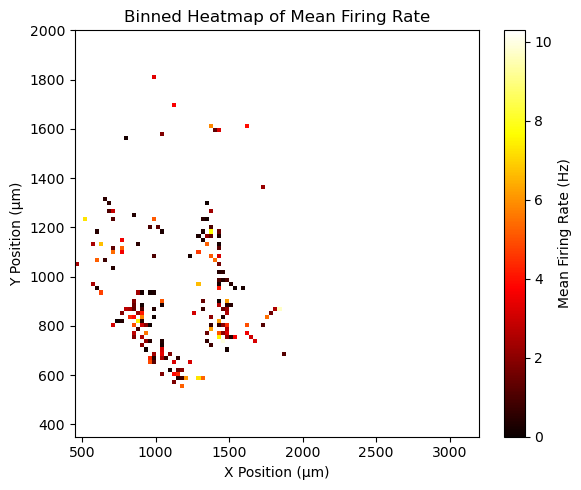

In [37]:
plot_firing_rate_heatmap_binned(sd24578_49, bins = (100, 100), pos_range= ((450, 3200), (350, 2000)))

In [38]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def pca_on_matrix(matrix):
    """
    Perform PCA on an NxN matrix, treating each row as a sample of dimension N.
    Returns the PCA object (so you can access explained_variance_, etc.).
    """
    pca = PCA(n_components=None)  # keep all components
    pca.fit(matrix)  # shape (N, N)
    return pca


In [57]:
def plot_pca_combined(pca_list, pca_names_list, colors_list, title=None, output_path=None):
    """
    Plot the eigenvalue spectrum for multiple PCA objects on the same plot.
    """
    plt.figure(figsize=(8,6))
    for i, pca in enumerate(pca_list):
        dataset_name=pca_names_list[i]
        color=colors_list[i]
        eigenvals = pca.explained_variance_
        plt.plot(range(1, len(eigenvals)+1), eigenvals, 'o-', label=f"{dataset_name}", color=color)
    plt.xscale('linear')
    plt.yscale('log')
    plt.xlabel("Eigenvector Index")
    plt.ylabel("Eigenvalue (log scale)")
    plt.title("Eigenvalue Spectrum of Neuron Density")
    plt.legend()
    plt.tight_layout()
    if output_path:
        os.makedirs(output_path, exist_ok=True)
        plt.savefig(os.path.join(output_path, f"pca_{title}.png"))
        plt.close()
    else:
        plt.show()

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter

def plot_firing_rate_overlay(
    neuron_positions,
    firing_rates,
    background_image_path=None,
    bins=30,
    pos_range=None,
    sigma=0.65,
    alpha=0.6,
    cmap="inferno",
    vmin=None,
    vmax=None,
    output_path=None
):
    """
    Overlay a smoothed 2D histogram of neuron firing rates on an optional background image.

    Steps:
      1. Optionally load and display a background image (if background_image_path is not None).
      2. Compute a 2D histogram of neuron positions weighted by firing_rates.
      3. Apply a Gaussian filter to smooth it.
      4. Mask out bins that are zero (no neurons).
      5. Plot the heatmap with some transparency.
      6. Add a colorbar with the specified vmin/vmax range.

    Parameters:
      neuron_positions : np.ndarray
          Array of shape (N, 2), with each row = (x, y) for a neuron.
      firing_rates : np.ndarray
          Array of shape (N,) with the mean firing rate (or other metric) for each neuron.
      background_image_path : str or None
          If provided, the path to a background image (e.g. histology).
      bins : int or (int, int), default 30
          Number of bins along x and y or a 2-tuple of bins for 2D histogram.
      pos_range : list of [ [xmin, xmax], [ymin, ymax] ] or None
          The range for the 2D histogram. If None, computed from data.
      sigma : float, default 0.65
          Standard deviation for Gaussian filter.
      alpha : float, default 0.6
          Transparency of the overlaid heatmap.
      cmap : str, default "inferno"
          Colormap for the heatmap.
      vmin, vmax : float or None
          Minimum and maximum values for the color scale. If None, derived from data.
      output_path : str or None
          If provided, save the figure to this path. Otherwise, display interactively.

    Example usage:
    --------------
    plot_firing_rate_overlay(
        neuron_positions=pos_array,
        firing_rates=fr_array,
        background_image_path="my_background.png",
        bins=30,
        pos_range=[[0,1750],[0,1750]],
        sigma=0.65,
        alpha=0.6,
        cmap="inferno",
        vmin=0,
        vmax=12
    )
    """
    # If no range is provided, compute from data with a small margin.
    if pos_range is None:
        margin = 0.05
        xmin, xmax = neuron_positions[:,0].min(), neuron_positions[:,0].max()
        ymin, ymax = neuron_positions[:,1].min(), neuron_positions[:,1].max()
        x_margin = (xmax - xmin)*margin
        y_margin = (ymax - ymin)*margin
        pos_range = [[xmin - x_margin, xmax + x_margin],
                     [ymin - y_margin, ymax + y_margin]]

    # 1. Optionally load background image
    bg_img = None
    if background_image_path is not None and os.path.isfile(background_image_path):
        bg_img = plt.imread(background_image_path)

    # 2. Compute a 2D histogram weighted by firing rates
    # pos_range is expected in form [[xmin, xmax],[ymin, ymax]] for np.histogram2d
    heatmap, xedges, yedges = np.histogram2d(
        neuron_positions[:,0], neuron_positions[:,1],
        bins=bins,
        range=pos_range,
        weights=firing_rates
    )
    # Also compute a 2D histogram of counts to handle average
    count_map, _, _ = np.histogram2d(
        neuron_positions[:,0], neuron_positions[:,1],
        bins=bins,
        range=pos_range
    )
    # Convert the sum-of-rates to average rates per bin
    with np.errstate(divide='ignore', invalid='ignore'):
        avg_rate_map = heatmap / count_map
    avg_rate_map[count_map == 0] = 0  # or np.nan if you prefer

    # 3. Smooth with Gaussian filter
    avg_rate_map_smooth = gaussian_filter(avg_rate_map, sigma=sigma)

    # 4. Mask out zero bins if desired
    # For example, if you want to hide bins with zero coverage:
    masked_map = np.ma.masked_where(count_map == 0, avg_rate_map_smooth)

    # 5. Plot
    fig = plt.figure(figsize=(6,5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.05])
    ax_main = plt.subplot(gs[0])
    ax_cbar = plt.subplot(gs[1])

    if bg_img is not None:
        # Plot background image first
        # We assume the image is in the same coordinate system, so we set extent
        (xmin, xmax), (ymin, ymax) = pos_range
        ax_main.imshow(bg_img, extent=[xmin, xmax, ymin, ymax], aspect='auto')

    # X and Y edges define bin boundaries
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

    # If user doesn't provide vmin/vmax, derive them from the data
    if vmin is None:
        vmin = masked_map.min()
    if vmax is None:
        vmax = masked_map.max()

    # Create color normalization
    norm = Normalize(vmin=vmin, vmax=vmax)

    # Show the heatmap
    img = ax_main.imshow(
        masked_map.T,  # transpose so x is horizontal, y is vertical
        origin='lower',
        extent=extent,
        aspect='auto',
        cmap=cmap,
        norm=norm,
        alpha=alpha,
        interpolation='bilinear'
    )

    ax_main.set_title("Firing Rate Overlay")
    ax_main.set_xlabel("X Position (µm)")
    ax_main.set_ylabel("Y Position (µm)")

    # 6. Add colorbar
    cbar = plt.colorbar(img, cax=ax_cbar)
    cbar.set_label("Firing Rate (Hz)")

    plt.tight_layout()

    # Save or show
    if output_path:
        plt.savefig(output_path)
        plt.close(fig)
        print(f"Saved figure to: {output_path}")
    else:
        plt.show()


In [39]:
positions_24481_49 = get_neuron_positions(sd24481_49)
firing_rates_24481_49 = mean_firing_rates(sd24481_49)

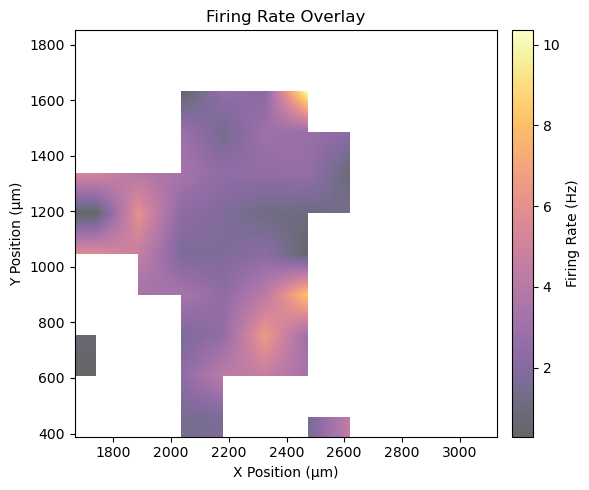

In [53]:
plot_firing_rate_overlay(positions_24481_49, firing_rates_24481_49, bins=(10, 10), sigma=0)